# Perfis dos municípios

Este notebook descreve os perfis formados pela partição escolhida pelo grupo
no notebook 05: quantos municípios cada perfil reúne, em que variáveis ele
fica acima ou abaixo da média do estado, quanto valem essas variáveis em
unidades originais e quais municípios o representam. Responde à pergunta
(iii) do artigo, sobre os perfis que emergem dos dados.

Saídas:

- **Figura 5** do artigo (`figura5_perfis`): a média padronizada de cada
  feature em cada perfil;
- `data/processed/tabela_perfis.csv`: as medianas de cada perfil em unidades
  originais;
- `data/processed/tabela_exemplos_perfis.csv`: os municípios mais típicos e
  os mais populosos de cada perfil.

O modelo usado é o registrado em `ALGORITMO_ESCOLHIDO` e `K_ESCOLHIDO`, no
`config.py`, e é impresso pela primeira célula de código. Os perfis vêm
numerados em ordem crescente de condição socioeconômica (o perfil 1 é o de
menor condição), critério definido no notebook 05. Os nomes dos perfis são
definidos pelo grupo e não constam deste notebook.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Os notebooks ficam em notebooks/ e o código do projeto em src/. Estas duas
# linhas apontam o Python para src/, para os "from config import ..." abaixo
# funcionarem tanto rodando daqui quanto da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from config import (ALGORITMO_ESCOLHIDO, BASE_FINAL_CSV, DATA_PROCESSED,
                    DICIONARIO_CSV, K_ESCOLHIDO)
from estilo import aplicar_estilo, salvar
from figuras import plot_perfis
from preprocessamento import ORDEM_BLOCOS, carregar_features, montar_matriz

aplicar_estilo()   # mesma fonte, cores e grade em todas as figuras do artigo
# Se algum import acima falhar, quase sempre é o editor apontando para outra
# instalação do Python. O caminho impresso aqui é o que precisa ter as
# bibliotecas do requirements.txt.
print("Python:", sys.executable)
print(f"Modelo escolhido: {ALGORITMO_ESCOLHIDO}, k = {K_ESCOLHIDO}")

# O código do IBGE é identificador, não quantidade: lido como texto para não
# virar número em nenhuma etapa.
base = pd.read_csv(BASE_FINAL_CSV, dtype={"codigo_ibge": str})
dic = pd.read_csv(DICIONARIO_CSV)
perfis = pd.read_csv(DATA_PROCESSED / "perfis.csv", dtype={"codigo_ibge": str})

Python: D:\RP 2\database-rp2\.venv\Scripts\python.exe
Modelo escolhido: kmeans, k = 4


## 1. Tamanho dos perfis

A tabela mostra, para cada perfil, o número de municípios, a população
mediana e a porcentagem de municípios com menos de 5.000 habitantes
(`flag_pop_pequena`), nos quais as taxas por 100 mil habitantes são menos
estáveis.

In [2]:
# Mesmo filtro do notebook 05: sem a capital, que não tem IEGM.
modelagem = base[~base["flag_sem_iegm"]].reset_index(drop=True)
# O perfis.csv foi salvo na mesma ordem de municípios; conferimos antes de
# juntar, porque a Figura 5 depende dessa ordem.
assert (modelagem["codigo_ibge"] == perfis["codigo_ibge"]).all(), \
    "perfis.csv fora da ordem da base"
assert perfis["perfil"].nunique() == K_ESCOLHIDO, "número de perfis diferente do config"
modelagem = modelagem.merge(perfis[["codigo_ibge", "perfil",
                                    "distancia_ao_centro", "divisao_k2"]],
                            on="codigo_ibge")

tamanho = modelagem.groupby("perfil").agg(
    municipios=("codigo_ibge", "size"),
    populacao_mediana=("populacao", "median"),
    # A média de uma coluna True/False é a proporção de True.
    pct_pequenos=("flag_pop_pequena", "mean"),
)
tamanho["pct_pequenos"] = (100 * tamanho["pct_pequenos"]).round(1)
tamanho

,municipios,populacao_mediana,pct_pequenos
perfil,,,
1,66,8444.0,25.8
2,217,4706.0,53.5
3,196,22575.5,4.6
4,165,53157.0,4.2


O notebook 05 registrou também a divisão mais robusta em dois grupos
(`divisao_k2`, K-means com k = 2), numerada pelo mesmo critério
socioeconômico. A tabela cruzada mostra quantos municípios de cada perfil
caem em cada um dos dois grupos, isto é, como os perfis se encaixam nessa
divisão.

In [3]:
# crosstab conta quantos municípios há em cada combinação perfil x grupo.
pd.crosstab(modelagem["perfil"], modelagem["divisao_k2"],
            rownames=["perfil"], colnames=["divisao_k2"], margins=True,
            margins_name="total")

divisao_k2,1,2,total
perfil,,,
1,66,0,66
2,211,6,217
3,64,132,196
4,1,164,165
total,342,302,644


Os perfis 1 e 2 caem quase inteiramente no grupo 1 da divisão em dois
(66 de 66 e 211 de 217), e o perfil 4, no grupo 2 (164 de 165). O perfil 3
se divide entre os dois grupos (64 e 132 municípios). O perfil 2 concentra
os municípios pequenos: 53,5% dos seus municípios têm menos de 5.000
habitantes, contra 4,6% no perfil 3 e 4,2% no perfil 4.

## 2. Figura 5 - perfis em relação à média

Cada célula mostra a média de uma feature em um perfil, medida em desvios em
relação à média dos 644 municípios: valores positivos (azul) indicam que o
perfil fica acima da média do estado, e negativos (vermelho), abaixo. As
médias são calculadas na matriz padronizada **sem** o peso por bloco (`Z`).
O peso por bloco multiplica cada coluna por um número menor que 1, o que
encolheria todos os valores e deixaria as cores apagadas, sem mudar quem fica
acima ou abaixo da média. Nas variáveis de gestão, que são notas, valores
acima da média indicam gestão mais bem avaliada pelo IEGM.

WindowsPath('D:/RP 2/database-rp2/figuras/figura5_perfis.png')

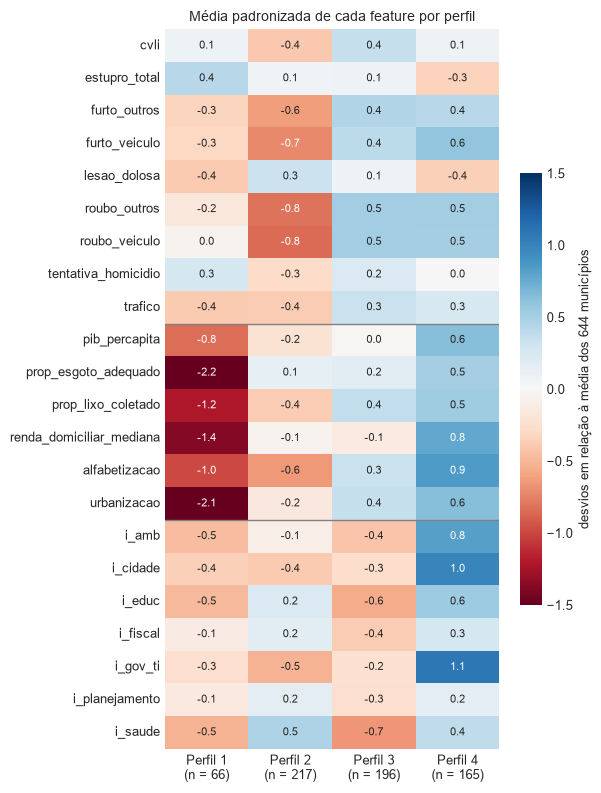

In [4]:
features, bloco_de = carregar_features(dic)
# Z: log1p e padronização, sem o peso por bloco. É a mesma Z do notebook 05.
Z, W, peso = montar_matriz(modelagem, features, bloco_de)

# groupby(...).mean() dá uma linha por perfil; .T vira a tabela para ficar
# com uma linha por feature, como no mapa de calor.
medias = Z.groupby(modelagem["perfil"]).mean().T
rotulos_perfis = [f"Perfil {p}\n(n = {n})"
                  for p, n in tamanho["municipios"].items()]
fig = plot_perfis(medias, bloco_de, ORDEM_BLOCOS, rotulos_perfis)
salvar(fig, "figura5_perfis")

## 3. Os perfis em unidades originais

O mapa de calor indica se um perfil fica acima ou abaixo da média; a tabela
abaixo indica quanto. São as medianas de cada perfil nas unidades da base
(taxas por 100 mil habitantes por ano, reais e porcentagens), sem
transformação, e uma última linha com a mediana dos 644 municípios. O
`iegm_ord` (índice geral do IEGM) não é feature e aparece apenas como
contexto.

In [5]:
colunas_tabela = ["populacao", "taxa_cvli", "taxa_roubo_outros",
                  "taxa_furto_outros", "taxa_estupro_total",
                  "renda_domiciliar_mediana", "pib_percapita",
                  "taxa_urbanizacao", "prop_esgoto_adequado",
                  "taxa_alfabetizacao", "iegm_ord"]
tabela_perfis = modelagem.groupby("perfil")[colunas_tabela].median()
tabela_perfis.loc["total"] = modelagem[colunas_tabela].median()
tabela_perfis.insert(0, "municipios",
                     list(tamanho["municipios"]) + [len(modelagem)])
tabela_perfis = tabela_perfis.round(2)
tabela_perfis.to_csv(DATA_PROCESSED / "tabela_perfis.csv")
tabela_perfis

,municipios,populacao,taxa_cvli,taxa_roubo_outros,taxa_furto_outros,taxa_estupro_total,renda_domiciliar_mediana,pib_percapita,taxa_urbanizacao,prop_esgoto_adequado,taxa_alfabetizacao,iegm_ord
perfil,,,,,,,,,,,,
1,66,8444.0,7.88,25.99,544.25,52.29,941.66,27329.21,60.81,69.49,93.28,1.00
2,217,4706.0,3.71,10.30,469.31,46.07,1200.00,38767.31,85.55,92.71,93.80,1.67
3,196,22575.5,7.10,46.24,722.21,41.51,1175.00,45832.29,93.19,94.68,95.58,1.00
4,165,53157.0,5.26,51.36,725.16,32.12,1258.33,62956.14,96.48,97.26,96.53,2.00
total,644,13285.0,5.75,27.85,620.93,40.58,1200.00,45480.16,90.54,94.45,95.00,1.33


## 4. Municípios de cada perfil

Para cada perfil, são listados dois tipos de exemplo. Os **típicos** são os
cinco municípios mais próximos do centro do perfil (menor
`distancia_ao_centro`, calculada no notebook 05) e representam bem o perfil.
Os **populosos** são os três maiores em população: nomes que o leitor tende a
reconhecer, mas que podem estar longe do centro.

In [6]:
exemplos = []
for p, grupo in modelagem.groupby("perfil"):
    # nsmallest/nlargest pegam as linhas com os menores/maiores valores.
    tipicos = grupo.nsmallest(5, "distancia_ao_centro").assign(tipo="típico")
    populosos = grupo.nlargest(3, "populacao").assign(tipo="populoso")
    exemplos += [tipicos, populosos]
exemplos = pd.concat(exemplos)[["perfil", "tipo", "codigo_ibge", "municipio",
                                "populacao", "distancia_ao_centro"]]
exemplos["distancia_ao_centro"] = exemplos["distancia_ao_centro"].round(3)
exemplos.to_csv(DATA_PROCESSED / "tabela_exemplos_perfis.csv", index=False)
exemplos

,perfil,tipo,codigo_ibge,municipio,populacao,distancia_ao_centro
98,1,típico,3508702,Caconde,17266,0.932
279,1,típico,3524600,Jacupiranga,16254,1.006
481,1,típico,3543006,Ribeirão Branco,18930,1.015
400,1,típico,3535606,Paraibuna,17950,1.052
578,1,típico,3552007,Silveiras,6313,1.065
225,1,populoso,3519709,Ibiúna,77651,1.569
425,1,populoso,3537800,Piedade,54237,1.525
579,1,populoso,3552106,Socorro,41405,1.513
588,2,típico,3552908,Taciba,6399,0.767
585,2,típico,3552601,Tabapuã,11499,0.876


## 5. Leitura dos perfis

Cada célula abaixo resume um perfil a partir da Figura 5 (valores em desvios
em relação à média dos 644 municípios), da tabela da seção 3 (medianas, entre
parênteses a mediana dos 644) e dos exemplos da seção 4. Os nomes dos perfis
serão definidos pelo grupo.

### Perfil 1 (66 municípios)

**Nome:** [a definir pelo grupo]

- **Condição socioeconômica muito abaixo da média**, o traço mais forte de
  todos os perfis: esgoto adequado (−2,2), urbanização (−2,1), renda
  domiciliar mediana (−1,4), coleta de lixo (−1,2) e alfabetização (−1,0). A
  urbanização mediana é de 60,81% (90,54%), o esgoto adequado de 69,49%
  (94,45%) e a renda mediana de R$ 941,66 (R$ 1.200,00).
- **Crimes contra a pessoa um pouco acima da média**: estupro (+0,4) e
  tentativa de homicídio (+0,3). A taxa mediana de estupro é de 52,29 por
  100 mil hab./ano (40,58) e a de CVLI, de 7,88 (5,75).
- **Crimes patrimoniais perto ou abaixo da média** (furtos −0,3; roubo de
  outros −0,2), com roubo mediano de 25,99 (27,85).
- **Gestão abaixo da média** em meio ambiente, educação e saúde (−0,5 cada).
- Municípios típicos: Caconde, Jacupiranga, Ribeirão Branco, Paraibuna e
  Silveiras. Mais populosos: Ibiúna, Piedade e Socorro.

### Perfil 2 (217 municípios)

**Nome:** [a definir pelo grupo]

- **Crimes patrimoniais bem abaixo da média**: roubo de outros e roubo de
  veículo (−0,8), furto de veículo (−0,7) e furto de outros (−0,6). O roubo
  mediano é de 10,30 por 100 mil hab./ano (27,85) e o furto, de 469,31
  (620,93). O CVLI também fica abaixo (−0,4), com mediana de 3,71 (5,75).
- **Municípios pequenos**: população mediana de 4.706 habitantes (13.285), e
  53,5% deles com menos de 5.000 habitantes.
- **Condição socioeconômica perto da média**, exceto alfabetização (−0,6) e
  coleta de lixo (−0,4). A renda mediana é de R$ 1.200,00, igual à do total.
- **Gestão mista**: saúde acima da média (+0,5), governança de tecnologia da
  informação (−0,5) e cidades (−0,4) abaixo.
- Municípios típicos: Taciba, Tabapuã, Neves Paulista, General Salgado e
  Pirajuí. Mais populosos: Rancharia, Mirandópolis e Pilar do Sul.

### Perfil 3 (196 municípios)

**Nome:** [a definir pelo grupo]

- **Crimes patrimoniais acima da média**: roubo de outros e roubo de veículo
  (+0,5), furtos (+0,4) e tráfico (+0,3). O roubo mediano é de 46,24 por 100
  mil hab./ano (27,85) e o furto, de 722,21 (620,93).
- **CVLI acima da média** (+0,4), com mediana de 7,10 (5,75), o maior valor
  entre os perfis depois do perfil 1.
- **Gestão abaixo da média**, sobretudo em saúde (−0,7) e educação (−0,6). A
  mediana do índice geral do IEGM é 1,00 (1,33).
- **Condição socioeconômica um pouco acima da média** em urbanização e
  coleta de lixo (+0,4), mas renda mediana de R$ 1.175,00 (R$ 1.200,00).
- Municípios típicos: Pitangueiras, Campos do Jordão, Torrinha, Ibitinga e
  Cajuru. Mais populosos: Mogi das Cruzes, Mauá e Carapicuíba.

### Perfil 4 (165 municípios)

**Nome:** [a definir pelo grupo]

- **Gestão acima da média**, o único perfil acima da média nas sete
  dimensões do IEGM, com destaque para governança de tecnologia da
  informação (+1,1), cidades (+1,0), meio ambiente (+0,8) e educação (+0,6). A mediana do índice geral do IEGM é 2,00 (1,33).
- **Condição socioeconômica acima da média**: alfabetização (+0,9), renda
  (+0,8), PIB per capita e urbanização (+0,6). A renda mediana é de
  R$ 1.258,33 (R$ 1.200,00) e o PIB per capita mediano, de R$ 62.956,14
  (R$ 45.480,16).
- **Crimes patrimoniais acima da média** (furto de veículo +0,6; roubos
  +0,5), com roubo mediano de 51,36 por 100 mil hab./ano (27,85), e **crimes
  contra a pessoa abaixo** (estupro −0,3; lesão dolosa −0,4), com estupro
  mediano de 32,12 (40,58).
- Municípios maiores: população mediana de 53.157 habitantes (13.285).
- Municípios típicos: Salto de Pirapora, Batatais, Olímpia, Jaboticabal e
  Matão. Mais populosos: Guarulhos, Campinas e São Bernardo do Campo.